# Nhiệm vụ 8 — Hồ sơ cụm PCA + K-Means

Input chính là `m2-task6-pca-kmeans-v1/cluster_profiles.csv`: đúng 13 cột phẳng,
không chứa JSON centroid. Scaler trong model chỉ được đọc để chuẩn hóa biểu đồ,
không fit lại. Mean/Median dưới đây là thống kê **qua 15 profile theo tháng**,
không phải median của mọi cổ phiếu gộp chung.
Thanh khoản trình bày bằng tỷ VND/phiên. Nhãn kỹ thuật Cụm 0/Cụm 1 được giữ trung tính.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Tìm root bằng file config, không phụ thuộc tên thư mục hoặc máy cá nhân.
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / 'configs/experiments/m2_task6_pca.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Chạy notebook từ repository hoặc M2/notebooks.')
sys.path.insert(0, str(ROOT / 'src'))
from delta_t1.experiments.protocol import validate_protocol
CONFIG = json.loads((ROOT / 'configs/experiments/m2_task6_pca.json').read_text(encoding='utf-8'))
validate_protocol(CONFIG)
FEATURES = CONFIG['clustering']['features']
DEV_DATES = CONFIG['development_snapshots']
K = CONFIG['clustering']['k']
TASK_DIR = ROOT / 'M2/artifacts/m2-task6-pca-kmeans-v1'
EVAL_DIR = ROOT / 'M2/artifacts/m2-evaluation-pca-kmeans'
REPORT_DIR = ROOT / 'M2/reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
print('Root:', ROOT)
print('Development:', DEV_DATES[0], '→', DEV_DATES[-1], '| Global K:', K)

def publish_csv(path, frame):
    content = frame.to_csv(index=False, lineterminator='\n').encode('utf-8')
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.read_bytes() != content:
        raise RuntimeError(f'CSV khác nội dung đã tồn tại: {path}; cần version mới.')
    if not path.exists():
        path.write_bytes(content)

def table_md(frame):
    def clean(value):
        return str(value).replace('|', '\\|').replace('\n', ' ')
    columns = frame.columns.tolist()
    lines = ['| ' + ' | '.join(map(clean, columns)) + ' |',
             '| ' + ' | '.join(['---'] * len(columns)) + ' |']
    for row in frame.itertuples(index=False, name=None):
        lines.append('| ' + ' | '.join(map(clean, row)) + ' |')
    return '\n'.join(lines)

Root: C:\Users\HOME\Desktop\M2\Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment
Development: 2023-11-30 → 2025-01-24 | Global K: 2


## 8.1 — Kiểm tra input profile và ba bảng chuẩn

In [2]:
# Fail-closed: chỉ đọc bộ v2 hoàn tất, có checksum và cùng config.
manifest = json.loads((TASK_DIR / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
assert manifest['config'] == CONFIG, 'Config thay đổi: cần run/version mới.'
for rel, expected in manifest['artifacts'].items():
    path = ROOT / rel
    assert hashlib.sha256(path.read_bytes()).hexdigest() == expected, f'Checksum mismatch: {rel}'

profiles = pd.read_csv(TASK_DIR / 'cluster_profiles.csv')
assert profiles.columns.tolist() == ['snapshot_date', 'raw_cluster_id', 'aligned_cluster_id', 'size', 'size_ratio', *FEATURES]
assert len(profiles) == 30 and sorted(profiles.snapshot_date.unique()) == DEV_DATES
assert not profiles.duplicated(['snapshot_date', 'aligned_cluster_id']).any()
assert profiles.groupby('snapshot_date').aligned_cluster_id.nunique().eq(K).all()
assert profiles['size'].gt(0).all() and np.isfinite(profiles[FEATURES].to_numpy(float)).all()
assert np.allclose(profiles.size_ratio, profiles['size']/profiles.groupby('snapshot_date')['size'].transform('sum'))
work = profiles.copy()
work['liquidity_21_ty_vnd'] = work.liquidity_21 / 1e9
TABLE_FEATURES = ['size', 'liquidity_21_ty_vnd', 'beta_126', 'vol_63', 'mdd_126', 'mom_21', 'mom_63', 'mom_126', 'mom_252']
table1_rows = []
for cluster in range(K):
    data = work[work.aligned_cluster_id.eq(cluster)]
    for statistic in ['mean', 'median']:
        values = data[TABLE_FEATURES].agg(statistic)
        table1_rows.append(dict(aligned_cluster_id=f'Cụm {cluster} ({statistic.title()})', **values.to_dict()))
table1 = pd.DataFrame(table1_rows)
means = work.groupby('aligned_cluster_id')[TABLE_FEATURES].mean()
table2 = pd.DataFrame({'Đặc trưng': TABLE_FEATURES,
    'Cụm 0 (Mean)': means.loc[0].values, 'Cụm 1 (Mean)': means.loc[1].values,
    'Chênh lệch (Cụm 0 - Cụm 1)': (means.loc[0]-means.loc[1]).values})
time = work.pivot(index='snapshot_date', columns='aligned_cluster_id', values=['size', 'liquidity_21_ty_vnd']).reindex(DEV_DATES)
table3 = pd.DataFrame({'Snapshot': DEV_DATES, 'Size Cụm 0': time['size'][0].to_numpy(),
    'Size Cụm 1': time['size'][1].to_numpy(), 'Liquidity Cụm 0 (tỷ VND)': time['liquidity_21_ty_vnd'][0].to_numpy(),
    'Liquidity Cụm 1 (tỷ VND)': time['liquidity_21_ty_vnd'][1].to_numpy()})
assert table1.shape == (4,10) and table2.shape == (9,4) and table3.shape == (15,5)
display(Markdown('### Bảng 1 — Mean và Median qua 15 tháng'))
display(table1.round(4))
display(Markdown('### Bảng 2 — So sánh đối đầu'))
display(table2.round(4))
display(Markdown('### Bảng 3 — Quy mô và thanh khoản theo tháng'))
display(table3.round(4))

### Bảng 1 — Mean và Median qua 15 tháng

,aligned_cluster_id,size,liquidity_21_ty_vnd,beta_126,vol_63,mdd_126,mom_21,mom_63,mom_126,mom_252
0,Cụm 0 (Mean),14.7333,371.8099,1.3013,0.2972,-0.1928,0.0265,0.0785,0.1335,0.3938
1,Cụm 0 (Median),15.0000,359.1518,1.2562,0.2959,-0.1773,0.0307,0.0749,0.1016,0.4123
2,Cụm 1 (Mean),359.6000,14.9442,0.6080,0.3537,-0.2109,0.0138,0.0290,0.0555,0.1877
3,Cụm 1 (Median),229.0000,14.2662,0.6200,0.3348,-0.2170,0.0096,0.0366,0.0397,0.1813


### Bảng 2 — So sánh đối đầu

,Đặc trưng,Cụm 0 (Mean),Cụm 1 (Mean),Chênh lệch (Cụm 0 - Cụm 1)
0,size,14.7333,359.6000,-344.8667
1,liquidity_21_ty_vnd,371.8099,14.9442,356.8657
2,beta_126,1.3013,0.6080,0.6933
3,vol_63,0.2972,0.3537,-0.0565
4,mdd_126,-0.1928,-0.2109,0.0181
5,mom_21,0.0265,0.0138,0.0127
6,mom_63,0.0785,0.0290,0.0495
7,mom_126,0.1335,0.0555,0.0780
8,mom_252,0.3938,0.1877,0.2061


### Bảng 3 — Quy mô và thanh khoản theo tháng

,Snapshot,Size Cụm 0,Size Cụm 1,Liquidity Cụm 0 (tỷ VND),Liquidity Cụm 1 (tỷ VND)
0,2023-11-30,9.0,133.0,201.2277,8.8951
1,2023-12-29,16.0,179.0,332.4347,14.5066
2,2024-01-31,17.0,179.0,295.1742,14.2662
3,2024-02-29,17.0,179.0,359.1518,16.6823
4,2024-03-29,15.0,182.0,492.0194,26.0962
5,2024-04-26,14.0,200.0,475.6056,23.6669
6,2024-05-31,15.0,206.0,419.7187,24.6562
7,2024-06-28,11.0,229.0,576.2641,29.3290
8,2024-07-31,17.0,230.0,323.0802,20.2449
9,2024-08-30,21.0,574.0,288.0955,6.7315


## 8.2–8.3 — Robust Z-Score và trực quan hóa

Z=(mean feature của cụm − median thị trường tháng đó)/IQR thị trường tháng đó.
Không fit scaler trên 30 centroid hoặc toàn bộ development.
Radar chỉ giới hạn **hiển thị** trong [-3,3], không clipping feature đầu vào;
những điểm ngoài biên có ký hiệu `*` và số liệu thật được giữ trong bảng.
Để polar plot hiển thị đúng giá trị âm, tọa độ vẽ là Z+3; nhãn trục vẫn là Z.
Heatmap 2×8 dùng RdBu_r, center=0, số annot giữ Z thật kể cả khi màu bão hòa.
Mặc định lưu snapshot cuối; Dropdown cho phép xem lại từng tháng.

### Robust Z-Score trung bình 15 tháng (không cắt dữ liệu)

,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
aligned_cluster_id,,,,,,,,
0,0.2710,0.4893,0.4910,0.6658,-0.0274,0.0289,0.8071,66.0005
1,0.1046,0.1338,0.1442,0.1687,0.1320,-0.1002,0.0380,1.4934


### Chênh lệch chuẩn hóa và động lực phân tách chính

,feature,delta_z_C0_minus_C1
7,liquidity_21,64.507073
6,beta_126,0.769094
3,mom_252,0.497022
1,mom_63,0.355528
2,mom_126,0.346727
0,mom_21,0.166424
4,vol_63,-0.159427
5,mdd_126,0.129089


Primary Driver: liquidity_21 | ΔZ = 64.5071


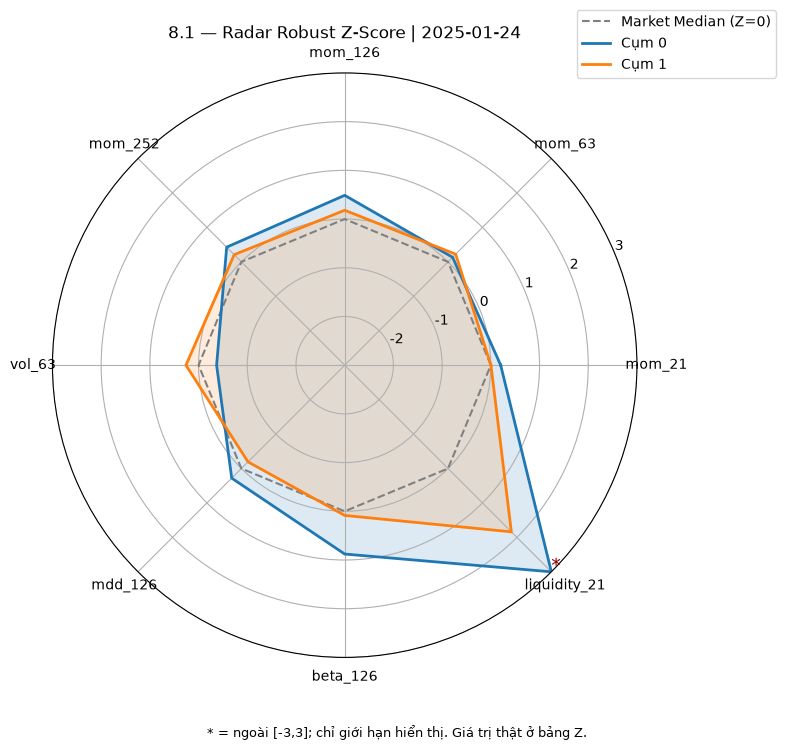

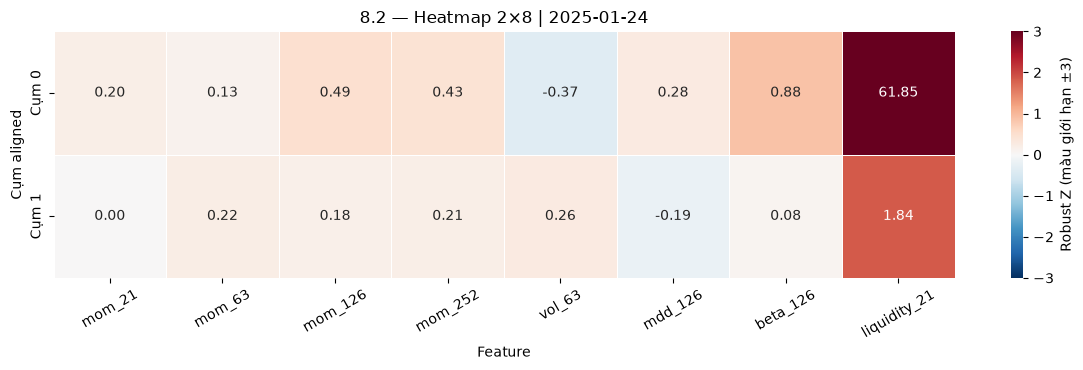

,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
aligned_cluster_id,,,,,,,,
0,0.2025,0.1333,0.4872,0.4263,-0.3704,0.2800,0.8773,61.8452
1,0.0026,0.2218,0.1809,0.2087,0.2590,-0.1929,0.0847,1.8390


In [3]:
z_rows = []
for row in profiles.itertuples(index=False):
    model = json.loads((TASK_DIR / f'models/{row.snapshot_date}.json').read_text(encoding='utf-8'))
    entry = dict(snapshot_date=row.snapshot_date, aligned_cluster_id=row.aligned_cluster_id)
    for feature in FEATURES:
        scaler = model['scaler'][feature]
        assert scaler['scale'] > 0
        entry[feature] = (getattr(row, feature)-scaler['center'])/scaler['scale']
    z_rows.append(entry)
z_scores = pd.DataFrame(z_rows)
z_means = z_scores.groupby('aligned_cluster_id')[FEATURES].mean()
driver_delta = z_means.loc[0] - z_means.loc[1]
driver = driver_delta.abs().idxmax()
display(Markdown('### Robust Z-Score trung bình 15 tháng (không cắt dữ liệu)'))
display(z_means.round(4))
display(Markdown('### Chênh lệch chuẩn hóa và động lực phân tách chính'))
display(pd.DataFrame({'feature': FEATURES, 'delta_z_C0_minus_C1': driver_delta.values}).sort_values('delta_z_C0_minus_C1', key=abs, ascending=False))
print('Primary Driver:', driver, '| ΔZ =', round(driver_delta[driver],4))

def plot_snapshot(day, save_figures=False):
    data = z_scores[z_scores.snapshot_date.eq(day)].set_index('aligned_cluster_id')[FEATURES].sort_index()
    angles = np.linspace(0, 2*np.pi, len(FEATURES), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'polar': True})
    ax.set_xticks(angles[:-1], FEATURES)
    ax.set_yticks(np.arange(7), [str(z) for z in range(-3,4)])
    ax.set_ylim(0,6)
    ax.plot(angles, [3]*9, color='gray', linestyle='--', label='Market Median (Z=0)')
    for cluster in range(K):
        true_z = data.loc[cluster].to_numpy(float)
        clipped = np.clip(true_z, -3,3) + 3
        ax.plot(angles, np.r_[clipped,clipped[0]], linewidth=2, label=f'Cụm {cluster}')
        ax.fill(angles, np.r_[clipped,clipped[0]], alpha=.15)
        for angle, position, value in zip(angles[:-1], clipped, true_z):
            if abs(value)>3:
                ax.annotate('*', (angle,position), color='darkred', fontsize=14)
    ax.set_title(f'8.1 — Radar Robust Z-Score | {day}', pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25,1.12))
    fig.text(.5,.02, '* = ngoài [-3,3]; chỉ giới hạn hiển thị. Giá trị thật ở bảng Z.', ha='center', fontsize=9)
    fig.tight_layout(rect=(0,.05,1,.97))
    if save_figures:
        fig.savefig(EVAL_DIR / 'radar_chart.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(12,3.8))
    import seaborn as sns
    sns.heatmap(data, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-3, vmax=3,
        linewidths=.5, yticklabels=['Cụm 0','Cụm 1'], ax=ax,
        cbar_kws={'label':'Robust Z (màu giới hạn ±3)'})
    ax.set(title=f'8.2 — Heatmap 2×8 | {day}', xlabel='Feature', ylabel='Cụm aligned')
    ax.tick_params(axis='x', rotation=30)
    fig.tight_layout()
    if save_figures:
        fig.savefig(EVAL_DIR / 'heatmap.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    display(data.round(4))

plot_snapshot(DEV_DATES[-1], save_figures=True)

In [4]:
# Widget chỉ đổi hình xem trong notebook; không ghi đè hình snapshot cuối đã bàn giao.
try:
    import ipywidgets as widgets
    selector = widgets.Dropdown(options=DEV_DATES, value=DEV_DATES[-1], description='Snapshot:')
    plot_output = widgets.Output()
    def on_snapshot_change(change):
        with plot_output:
            plot_output.clear_output(wait=True)
            plot_snapshot(change['new'])
    selector.observe(on_snapshot_change, names='value')
    display(selector, plot_output)
except ImportError:
    print('Không có ipywidgets: gọi plot_snapshot(ngày) để xem; snapshot cuối đã hiển thị.')

Dropdown(description='Snapshot:', index=14, options=('2023-11-30', '2023-12-29', '2024-01-31', '2024-02-29', '…

Output()

## 8.4 — Primary Driver, chân dung kinh tế và nhất quán theo thời gian

In [5]:
median_profiles = work.groupby('aligned_cluster_id')[TABLE_FEATURES].median()
mom = work.pivot(index='snapshot_date', columns='aligned_cluster_id', values='mom_63')
liq = work.pivot(index='snapshot_date', columns='aligned_cluster_id', values='liquidity_21_ty_vnd')
mom_higher = int(mom[0].gt(mom[1]).sum())
liq_higher = int(liq[0].gt(liq[1]).sum())
consistency = work[work.snapshot_date.isin(['2024-04-26','2024-07-31'])][
    ['snapshot_date','aligned_cluster_id','beta_126','mom_63','mdd_126']]
display(Markdown('### Profile ở 04/2024 và 07/2024: kiểm tra cụ thể, không suy đoán VN-Index'))
display(consistency.round(4))
conclusion = f"""# Báo cáo Nhiệm vụ 8 — Hồ sơ cụm PCA + K-Means

Nguồn profile và scaler: `m2-task6-pca-kmeans-v1`; không fit lại model/scaler.
Các thống kê Mean/Median tính qua profile tháng, không phải phân phối từng cổ phiếu.

## A — Chân dung kinh tế
Cụm 0: size mean={means.loc[0,'size']:.2f}, median={median_profiles.loc[0,'size']:.2f};
thanh khoản mean={means.loc[0,'liquidity_21_ty_vnd']:.2f}, median={median_profiles.loc[0,'liquidity_21_ty_vnd']:.2f} tỷ VND/phiên;
beta mean={means.loc[0,'beta_126']:.4f}, median={median_profiles.loc[0,'beta_126']:.4f}.
Cụm 1: size mean={means.loc[1,'size']:.2f}, median={median_profiles.loc[1,'size']:.2f};
thanh khoản mean={means.loc[1,'liquidity_21_ty_vnd']:.2f}, median={median_profiles.loc[1,'liquidity_21_ty_vnd']:.2f} tỷ VND/phiên;
beta mean={means.loc[1,'beta_126']:.4f}, median={median_profiles.loc[1,'beta_126']:.4f}.
Giữ nhãn Cụm 0/Cụm 1; không gán nhãn đầu tư từ một feature đơn lẻ.

## B — Động lực phân tách chính và tính nhất quán
Chênh lệch chuẩn hóa lớn nhất là {driver}: ΔZ={driver_delta[driver]:.4f};
Z mean C0={z_means.loc[0,driver]:.4f}, C1={z_means.loc[1,driver]:.4f}.
Cụm 0 có liquidity cao hơn ở {liq_higher}/15 tháng và mom_63 cao hơn ở {mom_higher}/15 tháng.
Điều này mô tả phân hóa đặc trưng, chưa chứng minh cơ chế dòng tiền hay quan hệ nhân quả.
Kiểm tra tháng 04/2024 và 07/2024 qua beta/momentum/MDD trong bảng riêng;
không kết luận về VN-Index khi notebook không đọc dữ liệu chỉ số.

## C — Tính khả thi cho M3
Thanh khoản là thông tin mô tả về khả năng giao dịch; mean chịu ảnh hưởng các mã cực đoan.
Chưa có size vốn, tỷ lệ tham gia volume, weights hoặc mô phỏng thực thi nên chưa thể
khẳng định đủ sức chứa hay không có slippage. Kiểm chứng chi phí thuộc M3.
Không khuyến nghị mua cụm nào, không sử dụng Sharpe/lợi nhuận hoặc holdout.
"""
display(Markdown(conclusion))
report = conclusion + '\n## Bảng 1\n' + table_md(table1.round(4)) + '\n## Bảng 2\n' + table_md(table2.round(4)) + '\n## Bảng 3\n' + table_md(table3.round(4))
report += '\n## Z trung bình theo scaler tháng\n' + table_md(z_means.reset_index().round(4))
report += '\n![Radar](../artifacts/m2-evaluation-pca-kmeans/radar_chart.png)\n![Heatmap](../artifacts/m2-evaluation-pca-kmeans/heatmap.png)\n'
(REPORT_DIR / 'Bao_cao_M2_Nhiem_vu_8_Ho_so_cum_PCA_KMeans.md').write_text(report, encoding='utf-8')
assert (EVAL_DIR/'radar_chart.png').stat().st_size > 0 and (EVAL_DIR/'heatmap.png').stat().st_size > 0

### Profile ở 04/2024 và 07/2024: kiểm tra cụ thể, không suy đoán VN-Index

,snapshot_date,aligned_cluster_id,beta_126,mom_63,mdd_126
10,2024-04-26,1,0.7109,0.0154,-0.1741
11,2024-04-26,0,1.3492,0.0386,-0.1747
16,2024-07-31,1,0.6611,0.0516,-0.1866
17,2024-07-31,0,1.2635,0.0867,-0.1773


# Báo cáo Nhiệm vụ 8 — Hồ sơ cụm PCA + K-Means

Nguồn profile và scaler: `m2-task6-pca-kmeans-v1`; không fit lại model/scaler.
Các thống kê Mean/Median tính qua profile tháng, không phải phân phối từng cổ phiếu.

## A — Chân dung kinh tế
Cụm 0: size mean=14.73, median=15.00;
thanh khoản mean=371.81, median=359.15 tỷ VND/phiên;
beta mean=1.3013, median=1.2562.
Cụm 1: size mean=359.60, median=229.00;
thanh khoản mean=14.94, median=14.27 tỷ VND/phiên;
beta mean=0.6080, median=0.6200.
Giữ nhãn Cụm 0/Cụm 1; không gán nhãn đầu tư từ một feature đơn lẻ.

## B — Động lực phân tách chính và tính nhất quán
Chênh lệch chuẩn hóa lớn nhất là liquidity_21: ΔZ=64.5071;
Z mean C0=66.0005, C1=1.4934.
Cụm 0 có liquidity cao hơn ở 15/15 tháng và mom_63 cao hơn ở 12/15 tháng.
Điều này mô tả phân hóa đặc trưng, chưa chứng minh cơ chế dòng tiền hay quan hệ nhân quả.
Kiểm tra tháng 04/2024 và 07/2024 qua beta/momentum/MDD trong bảng riêng;
không kết luận về VN-Index khi notebook không đọc dữ liệu chỉ số.

## C — Tính khả thi cho M3
Thanh khoản là thông tin mô tả về khả năng giao dịch; mean chịu ảnh hưởng các mã cực đoan.
Chưa có size vốn, tỷ lệ tham gia volume, weights hoặc mô phỏng thực thi nên chưa thể
khẳng định đủ sức chứa hay không có slippage. Kiểm chứng chi phí thuộc M3.
Không khuyến nghị mua cụm nào, không sử dụng Sharpe/lợi nhuận hoặc holdout.


## Kết luận A/B/C từ số liệu đã chạy

## A — Chân dung kinh tế
Cụm 0: size mean=14.73, median=15.00;
thanh khoản mean=371.81, median=359.15 tỷ VND/phiên;
beta mean=1.3013, median=1.2562.
Cụm 1: size mean=359.60, median=229.00;
thanh khoản mean=14.94, median=14.27 tỷ VND/phiên;
beta mean=0.6080, median=0.6200.
Giữ nhãn Cụm 0/Cụm 1; không gán nhãn đầu tư từ một feature đơn lẻ.

## B — Động lực phân tách chính và tính nhất quán
Chênh lệch chuẩn hóa lớn nhất là liquidity_21: ΔZ=64.5071;
Z mean C0=66.0005, C1=1.4934.
Cụm 0 có liquidity cao hơn ở 15/15 tháng và mom_63 cao hơn ở 12/15 tháng.
Điều này mô tả phân hóa đặc trưng, chưa chứng minh cơ chế dòng tiền hay quan hệ nhân quả.
Kiểm tra tháng 04/2024 và 07/2024 qua beta/momentum/MDD trong bảng riêng;
không kết luận về VN-Index khi notebook không đọc dữ liệu chỉ số.

## C — Tính khả thi cho M3
Thanh khoản là thông tin mô tả về khả năng giao dịch; mean chịu ảnh hưởng các mã cực đoan.
Chưa có size vốn, tỷ lệ tham gia volume, weights hoặc mô phỏng thực thi nên chưa thể
khẳng định đủ sức chứa hay không có slippage. Kiểm chứng chi phí thuộc M3.
Không khuyến nghị mua cụm nào, không sử dụng Sharpe/lợi nhuận hoặc holdout.